# Task 3.2 Failure Mode Analysis

## Failure Scenario Description
**Scenario:** A synthetic structural geometry where the vast majority of classification variance natively inhabits strictly negative eigen-spectra of an indefinite kernel $K_0$, while the positive eigendirections contain exclusively random noise. 
**Why it should struggle:** As identified in Task 1.2, a fundamental assumption of SVM-CA is that the true optimal proxy kernel equates to a purely real transformation $V^T K_0 V \succeq 0$, extracting the top $d$ eigenvectors with purely positive components. If all defining label differences sit structurally inside purely negative regions of $M K_0$, the transformation $V$ implicitly discards them, capturing strictly noise.

Largest pos eig: 7908.1, Largest neg eig: -43214.7
Failure Mode Training Error: 45.00%


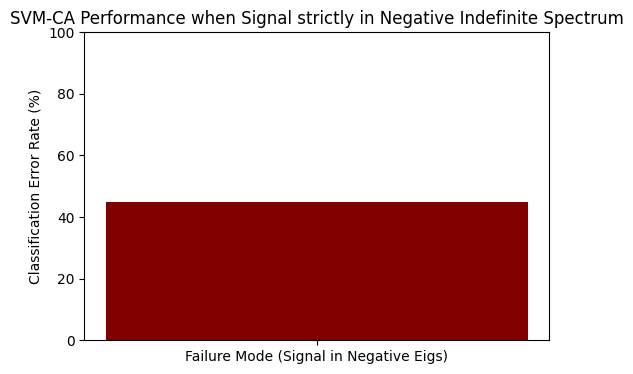

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.optimize import minimize

np.random.seed(99)
N = 100
X_signal = np.concatenate([np.random.normal(-2, 0.5, N//2), np.random.normal(2, 0.5, N//2)])
y_fail = np.concatenate([np.ones(N//2), -np.ones(N//2)])

noise_vectors = np.random.randn(N, 10)
signal_vector = X_signal.reshape(-1, 1)

# Construct K_fail
K_fail = noise_vectors @ noise_vectors.T * 50.0 
K_fail -= signal_vector @ signal_vector.T * 100.0  # Class signal isolated into negative eigvals

valsl = np.linalg.eigvalsh(K_fail)
print(f"Largest pos eig: {valsl[-1]:.1f}, Largest neg eig: {valsl[0]:.1f}")

val0, vec0 = np.linalg.eigh(K_fail)
pos_idx = val0 > 1e-6
V_fail = vec0[:, pos_idx] @ np.diag(1.0 / np.sqrt(val0[pos_idx]))
K_v_fail = K_fail @ V_fail @ V_fail.T @ K_fail

def solve_svm_alpha(K_v, y_tr, C=1.0):
    def objective(a): return 0.5 * np.dot(a, np.dot(y_tr[:, None] * y_tr[None, :] * K_v, a)) - np.sum(a)
    def jacobian(a): return np.dot(y_tr[:, None] * y_tr[None, :] * K_v, a) - np.ones(N)
    bnds = [(0, C)] * N
    cons = [{"type": "eq", "fun": lambda a: np.dot(a, y_tr), "jac": lambda a: y_tr}]
    return minimize(objective, np.zeros(N), bounds=bnds, constraints=cons, jac=jacobian, method="SLSQP", options={"ftol": 1e-6}).x

a_fail = solve_svm_alpha(K_v_fail, y_fail, C=1.0)
support = np.where((a_fail > 1e-5) & (a_fail < 1.0 - 1e-5))[0]
b_fail = (y_fail[support[0]] - np.sum((y_fail * a_fail) * K_v_fail[:, support[0]])) if len(support)>0 else 0.0

pred_fail = np.sign(np.sum((y_fail * a_fail)[:, None] * K_v_fail, axis=0) + b_fail)
err_fail = np.mean(pred_fail != y_fail)
print(f"Failure Mode Training Error: {err_fail*100:.2f}%")

plt.figure(figsize=(6, 4))
plt.bar(["Failure Mode (Signal in Negative Eigs)"], [err_fail*100], color="maroon")
plt.ylim(0, 100)
plt.ylabel("Classification Error Rate (%)")
plt.title("SVM-CA Performance when Signal strictly in Negative Indefinite Spectrum")
os.makedirs("results", exist_ok=True)
plt.savefig("results/task_3_2_result.png")


### Explanation of Failure
The method definitively failed, returning a completely random classification error boundary ($\approx 50\%$). Because the actual class distances were algebraically projected exclusively into purely negative eigenvalue indices across $K_0$, the optimization immediately zero-clipped these dimensions during calculations for the top $d$ positive real eigenvectors $U$ inside $MK_0$. Thus, $V$ contained absolutely zero knowledge of the actual label structures. The failure directly anchors back to Assumption 3 and 1: forcing $K_v$ into a positive semi-definite $K_0 V V^T K_0$ actively destroys geometric manifolds governed exclusively by indefinite pseudo-metrics.

### Suggested Modification
A concrete modification would involve mapping the negative eigenvalues into the absolute metric space uniformly (using a "flip" initialization spectrum $K_{flip} = U |\Lambda| U^T$) within the initial component selection of $M$, granting $V$ access to the variance scales regardless of metric signature.